In [30]:
%pip install pandas numpy matplotlib seaborn scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d

In [32]:
dataset=pd.read_csv("credit.csv")

In [33]:
dataset.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [34]:
dataset.drop(columns=["CUST_ID"],inplace=True)

In [35]:
dataset.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [36]:
print(dataset.info())
print(dataset.shape)

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT_LIMIT     

In [37]:
print(dataset.isnull().sum())

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [38]:
print(dataset.describe())


            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count   8950.000000        8950.000000   8950.000000       8950.000000   
mean    1564.474828           0.877271   1003.204834        592.437371   
std     2081.531879           0.236904   2136.634782       1659.887917   
min        0.000000           0.000000      0.000000          0.000000   
25%      128.281915           0.888889     39.635000          0.000000   
50%      873.385231           1.000000    361.280000         38.000000   
75%     2054.140036           1.000000   1110.130000        577.405000   
max    19043.138560           1.000000  49039.570000      40761.250000   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count             8950.000000   8950.000000          8950.000000   
mean               411.067645    978.871112             0.490351   
std                904.338115   2097.163877             0.401371   
min                  0.000000      0.000000             0.000

In [39]:
print(dataset['MINIMUM_PAYMENTS'].mean())
print(dataset['MINIMUM_PAYMENTS'].median())

864.2065423050826
312.343947


In [40]:
dataset["MINIMUM_PAYMENTS"] = dataset["MINIMUM_PAYMENTS"].fillna(dataset["MINIMUM_PAYMENTS"].median())
dataset["CREDIT_LIMIT"] = dataset["CREDIT_LIMIT"].fillna(dataset["CREDIT_LIMIT"].mean())

In [41]:
print(dataset.isnull().sum())

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


In [42]:
dataset.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='str')

In [43]:
kmeans = KMeans(n_clusters=6, random_state=42)
y_kmeans = kmeans.fit_predict(dataset)

In [44]:
y_kmeans

array([1, 5, 3, ..., 1, 1, 1], shape=(8950,), dtype=int32)

In [45]:
dataset['Cluster'] = y_kmeans

In [46]:
dataset['Cluster'] 

0       1
1       5
2       3
3       3
4       1
       ..
8945    1
8946    1
8947    1
8948    1
8949    1
Name: Cluster, Length: 8950, dtype: int32

In [47]:
print(sorted(dataset['Cluster'].unique()))

[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]


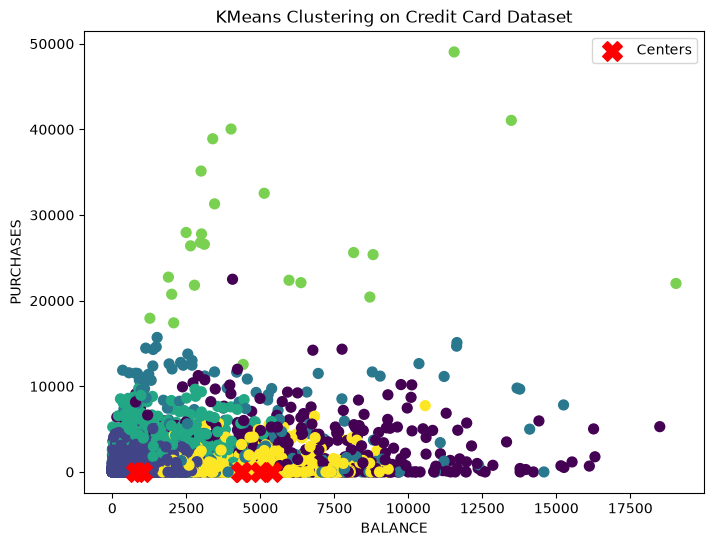

In [48]:
# Step 4: Visualize clusters using 2D (first two features)
plt.figure(figsize=(8,6))
plt.scatter(dataset.iloc[:,0], dataset.iloc[:,2], c=dataset['Cluster'], cmap='viridis', s=50)

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label="Centers")

plt.xlabel(dataset.columns[0])
plt.ylabel(dataset.columns[2])
plt.title("KMeans Clustering on Credit Card Dataset")
plt.legend()
plt.show()

In [49]:
# BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE

sample = [[2000, 0.8, 1500, 200, 300, 100, 0.5, 0.1, 0.3, 0.2, 2, 15, 15000, 1000, 150, 0.1, 12]]
predicted_cluster = kmeans.predict(sample)
print(f"The sample belongs to cluster: {predicted_cluster[0]}")

The sample belongs to cluster: 0


/Users/macbookair/Desktop/ML/VE/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [50]:
# Whats the Average Balance of CLuster 0,1,2
cluster1 = dataset[dataset['Cluster'] == 0]
cluster2 = dataset[dataset['Cluster'] == 1]
# cluster3 = dataset[dataset['Cluster'] == 2]
# cluster4 = dataset[dataset['Cluster'] == 3]

print("Average Balance of Cluster 0:", cluster1['BALANCE'].mean())
print("Average Balance of Cluster 1:", cluster2['BALANCE'].mean())
# print("Average Balance of Cluster 2:", cluster3['BALANCE'].mean())
# print("Average Balance of Cluster 3:", cluster4['BALANCE'].mean())

Average Balance of Cluster 0: 5004.064338685149
Average Balance of Cluster 1: 784.5081534795671


In [51]:
# Whats the Average Credit Limit of CLuster 0,1,2
cluster1 = dataset[dataset['Cluster'] == 0]
cluster2 = dataset[dataset['Cluster'] == 1]
cluster3 = dataset[dataset['Cluster'] == 2]
cluster4 = dataset[dataset['Cluster'] == 3]

print("Average Credit Limit of Cluster 0:", cluster1['CREDIT_LIMIT'].mean())
print("Average Credit Limit of Cluster 1:", cluster2['CREDIT_LIMIT'].mean())
print("Average Credit Limit of Cluster 2:", cluster3['CREDIT_LIMIT'].mean())
print("Average Credit Limit of Cluster 3:", cluster4['CREDIT_LIMIT'].mean())

Average Credit Limit of Cluster 0: 13440.198019801981
Average Credit Limit of Cluster 1: 2188.8844321090437
Average Credit Limit of Cluster 2: 10048.210612918552
Average Credit Limit of Cluster 3: 6916.983448749865


#Performance Metrics for Clustering

In [52]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [53]:
# Calculate clustering metrics
silhouette = silhouette_score(dataset, kmeans.labels_)
db_index = davies_bouldin_score(dataset, kmeans.labels_)
ch_index = calinski_harabasz_score(dataset, kmeans.labels_)

# Print the metric scores
print(f"Silhouette Score: {silhouette:.2f}")
print(f"Davies-Bouldin Index: {db_index:.2f}")
print(f"Calinski-Harabasz Index: {ch_index:.2f}")

Silhouette Score: 0.38
Davies-Bouldin Index: 1.32
Calinski-Harabasz Index: 2285.74


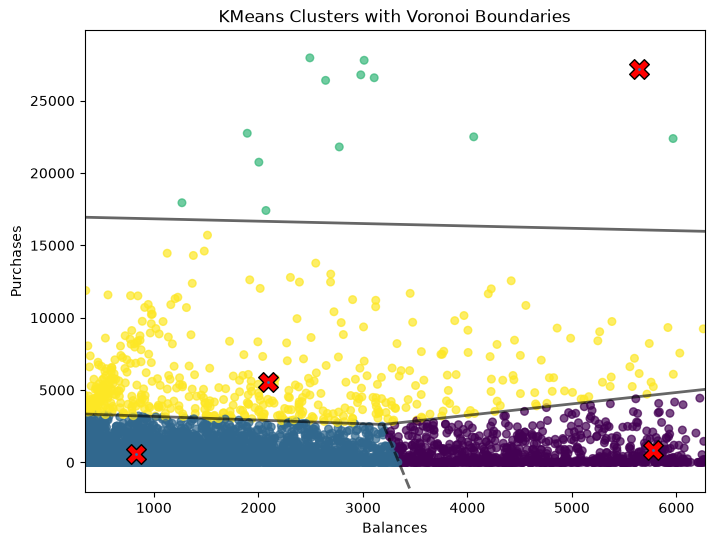

In [60]:
# Take only first 2 columns for visualization
X_2d = dataset[["BALANCE", "PURCHASES"]].values

# Fit KMeans again on 2D data
kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X_2d)
centers = kmeans.cluster_centers_

# Plot scatter
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_kmeans, cmap="viridis", s=30, alpha=0.7)

# Add Voronoi polygons
vor = Voronoi(centers)
voronoi_plot_2d(vor, ax=plt.gca(), show_vertices=False, line_colors='black', line_width=2, line_alpha=0.6, point_size=2)

# Plot cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, marker="X", edgecolors="black")

plt.xlabel("Balances")
plt.ylabel("Purchases")
plt.title("KMeans Clusters with Voronoi Boundaries")
plt.show()

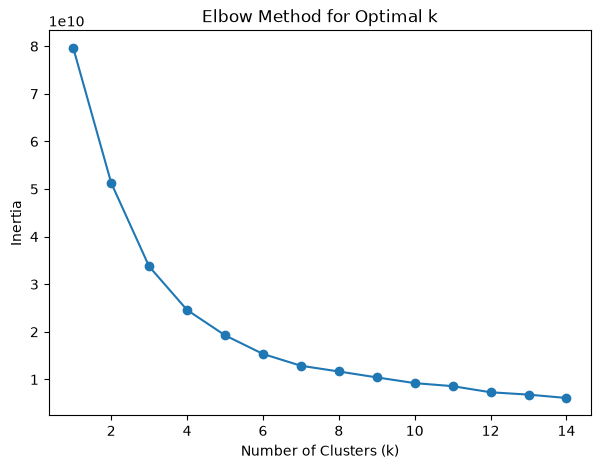

In [55]:
# Take only first 2 columns for visualization
X_2d = dataset[["BALANCE", "PURCHASES"]].values

inertia = []
for k in range(1, 15):
    km = KMeans(n_clusters=k, random_state=42).fit(X_2d)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1, 15), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

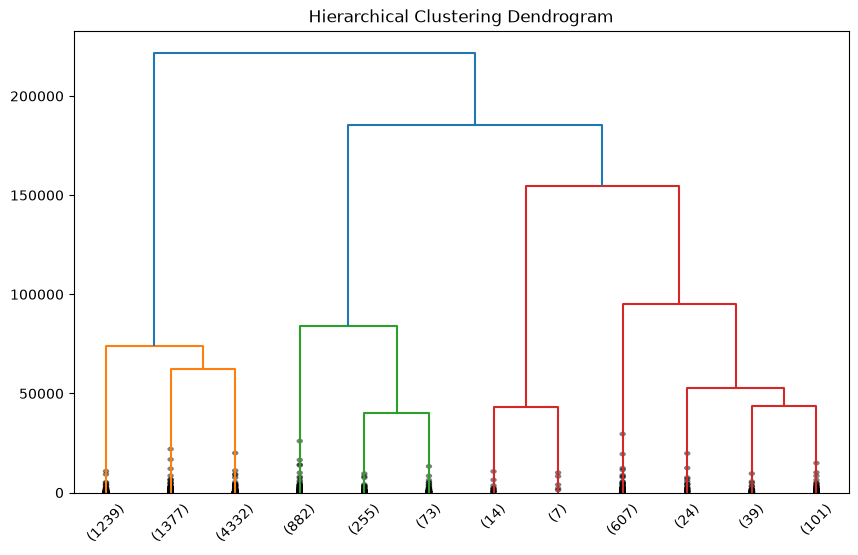

In [56]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_2d, 'ward')
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode="lastp", p=12, leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

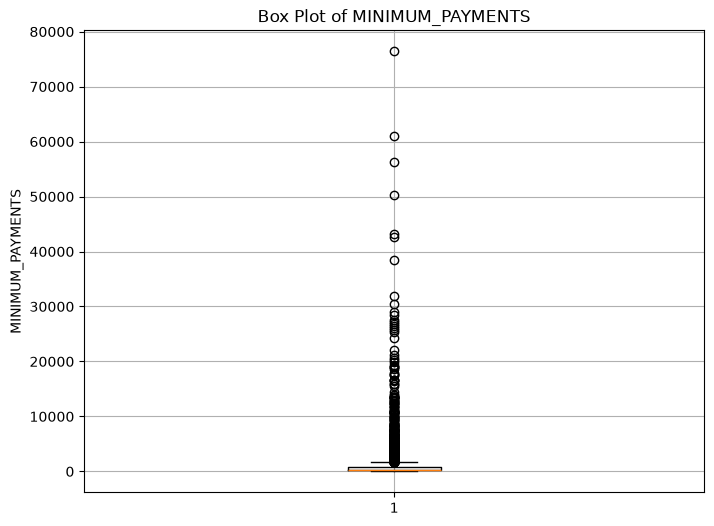

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.boxplot(dataset['MINIMUM_PAYMENTS'])
plt.title('Box Plot of MINIMUM_PAYMENTS')
plt.ylabel('MINIMUM_PAYMENTS')
plt.grid(True)
plt.show()

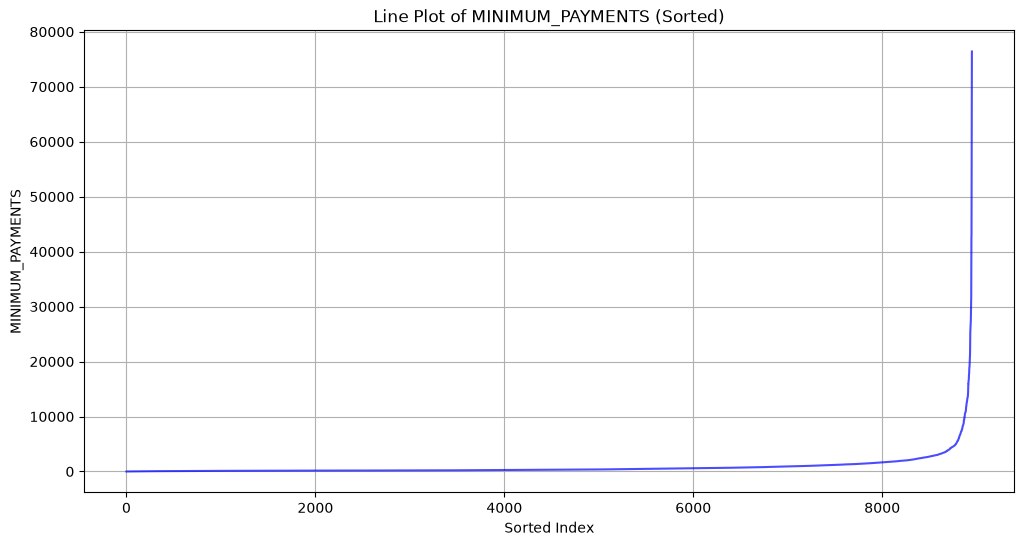

In [58]:
import matplotlib.pyplot as plt
import numpy as np

sorted_payments = np.sort(dataset['MINIMUM_PAYMENTS'].dropna().values)
plt.figure(figsize=(12,6))
plt.plot(sorted_payments, alpha=0.7, color='blue')
plt.title('Line Plot of MINIMUM_PAYMENTS (Sorted)')
plt.xlabel('Sorted Index')
plt.ylabel('MINIMUM_PAYMENTS')
plt.grid(True)
plt.show()